In [30]:
import os
from pathlib import Path
import sys

import pandas as pd

# Set working directory to project root (compatible with Jupyter notebooks)
try:
    project_root = Path(__file__).parent.parent
except NameError:
    # Running in Jupyter notebook
    project_root = Path.cwd()
    if project_root.name == 'src':
        project_root = project_root.parent

os.chdir(project_root)
src_path = str(project_root / 'src')
if src_path not in sys.path:
    sys.path.insert(0, src_path)

print(f"Working directory: {os.getcwd()}")
print(f"Python path includes: {src_path}")

from classifier import train_xgboost
from feature_combiner import combine_features
from preprocessing import clean_text_for_roberta, clean_text_for_tfidf
from roberta_embedder import extract_embeddings
from tfidf_vectorizer import compute_tfidf, save_vectorizer
from sklearn.preprocessing import StandardScaler

def _validate_schema(df: pd.DataFrame, file_name: str) -> None:
    required = {"content", "label"}
    missing = sorted(required.difference(df.columns))
    if missing:
        raise ValueError(f"{file_name} thiếu cột bắt buộc: {missing}")


def _encode_labels(label_series: pd.Series) -> pd.Series:
    if pd.api.types.is_numeric_dtype(label_series):
        numeric = pd.to_numeric(label_series, errors="coerce")
        if set(numeric.dropna().unique()).issubset({0, 1}):
            return numeric

    normalized = label_series.astype(str).str.strip().str.lower()
    mapping = {
        "truth": 0,
        "rumor": 1,
        "0": 0,
        "1": 1,
    }
    encoded = normalized.map(mapping)

    invalid_mask = encoded.isna()
    if invalid_mask.any():
        invalid_values = sorted(normalized[invalid_mask].unique().tolist())
        raise ValueError(
            "Chi nhan 2 nhan duoc phep: 'truth'->0 va 'rumor'->1. "
            f"Gia tri khong hop le: {invalid_values}"
        )

    return encoded


def _prepare_split(df: pd.DataFrame, split_name: str):
    print(f"\n[{split_name}] cleaning text...")
    df = df.copy()
    df["clean_text_tfidf"] = df["content"].apply(clean_text_for_tfidf)
    df["clean_text_roberta"] = df["content"].apply(clean_text_for_roberta)
    labels = _encode_labels(df["label"])
    valid = (~labels.isna()) & (~df["clean_text_roberta"].isna())

    dropped = int((~valid).sum())
    if dropped > 0:
        print(f"[{split_name}] bỏ {dropped} dòng do label/text không hợp lệ")

    df = df.loc[valid].reset_index(drop=True)
    labels = labels.loc[valid].astype(int).reset_index(drop=True)

    print(f"[{split_name}] samples hợp lệ: {len(df)}")
    print(f"[{split_name}] label distribution:\n{labels.value_counts().sort_index()}")

    return df, labels.values


Working directory: d:\HK8\hybrid-fake-news-detector
Python path includes: d:\HK8\hybrid-fake-news-detector\src


In [31]:
print("Loading train/test data...")
train_df = pd.read_csv("data/ver_1/train.csv")
test_df = pd.read_csv("data/ver_1/test.csv")

_validate_schema(train_df, "train.csv")
_validate_schema(test_df, "test.csv")

print(f"Train shape: {train_df.shape}")
print(f"Test shape:  {test_df.shape}")

train_df, y_train = _prepare_split(train_df, "TRAIN")
test_df, y_test = _prepare_split(test_df, "TEST")

print("\nGenerating TF-IDF features (fit on TRAIN)...")
X_train_tfidf, tfidf_vectorizer = compute_tfidf(train_df["clean_text_tfidf"])
X_test_tfidf, _ = compute_tfidf(test_df["clean_text_tfidf"], fitted_vectorizer=tfidf_vectorizer)

print("Generating RoBERTa embeddings...")
X_train_roberta = extract_embeddings(train_df["clean_text_roberta"])
X_test_roberta = extract_embeddings(test_df["clean_text_roberta"])

print("Combining text features...")
X_train = combine_features(X_train_tfidf, X_train_roberta)
X_test = combine_features(X_test_tfidf, X_test_roberta)

Loading train/test data...
Train shape: (1711, 4)
Test shape:  (428, 4)

[TRAIN] cleaning text...
[TRAIN] samples hợp lệ: 1711
[TRAIN] label distribution:
label
0    902
1    809
Name: count, dtype: int64

[TEST] cleaning text...
[TEST] samples hợp lệ: 428
[TEST] label distribution:
label
0    256
1    172
Name: count, dtype: int64

Generating TF-IDF features (fit on TRAIN)...
Generating RoBERTa embeddings...


Extracting RoBERTa embeddings: 100%|██████████| 428/428 [00:24<00:00, 17.18it/s]

Combining text features...


In [32]:
print("Training XGBoost classifier...")
results = train_xgboost(
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
)

print("\nSaving vectorizer...")
save_vectorizer(tfidf_vectorizer, "tfidf_vectorizer.pkl")
print("Done.")


Training XGBoost classifier...
Log loss curves saved to: logloss_train_test.png
Accuracy curves saved to: accuracy_train_test.png
Training curve values saved to: training_curves.json
Best round used for inference: 131

Training complete! Evaluating model...
Feature importance stats:
  Total features: 1803
  Non-zero importances: 599
  Max importance: 0.009352
  Mean importance: 0.000555

Top 20 features by importance:
  1. RoBERTa_dim_421: 0.009352
  2. TF-IDF: ferguson: 0.006880 → RUMOR (Rumor: 0.0262, Truth: 0.0034)
  3. RoBERTa_dim_615: 0.006877
  4. RoBERTa_dim_652: 0.005653
  5. RoBERTa_dim_136: 0.005346
  6. RoBERTa_dim_409: 0.005117
  7. RoBERTa_dim_253: 0.005097
  8. RoBERTa_dim_559: 0.004509
  9. RoBERTa_dim_67: 0.004503
  10. RoBERTa_dim_162: 0.004354
  11. RoBERTa_dim_738: 0.004176
  12. RoBERTa_dim_5: 0.004103
  13. RoBERTa_dim_591: 0.004019
  14. RoBERTa_dim_597: 0.003995
  15. RoBERTa_dim_231: 0.003820
  16. RoBERTa_dim_374: 0.003810
  17. RoBERTa_dim_110: 0.003788
  18. 

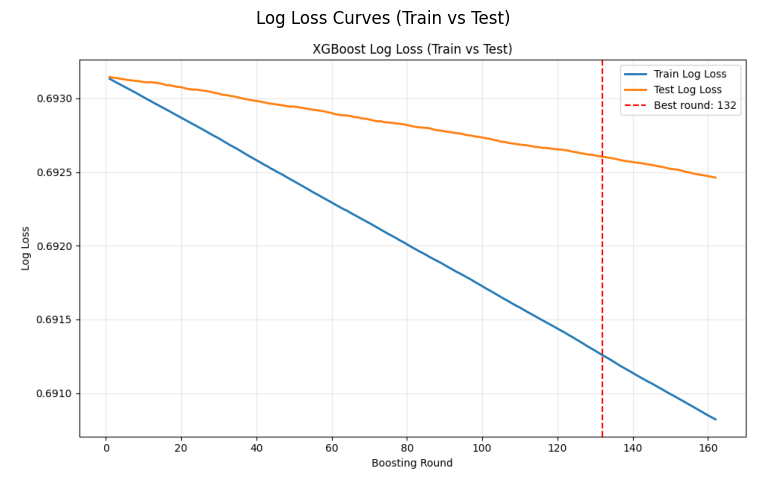

In [33]:
# Display Training Loss Curves
from PIL import Image
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 5))
img = Image.open("logloss_train_test.png")
ax.imshow(img)
ax.axis('off')
plt.title("Log Loss Curves (Train vs Test)")
plt.tight_layout()
plt.show()


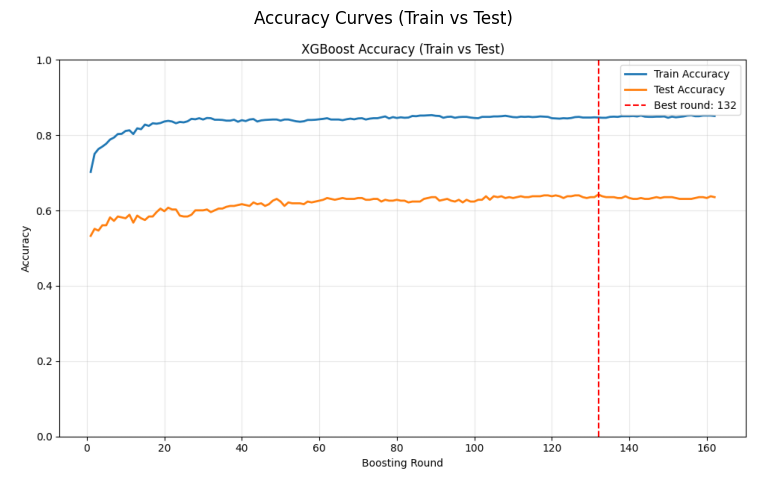

In [34]:
# Display Training Accuracy Curves
from PIL import Image
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 5))
img = Image.open("accuracy_train_test.png")
ax.imshow(img)
ax.axis('off')
plt.title("Accuracy Curves (Train vs Test)")
plt.tight_layout()
plt.show()


In [35]:
# Display Evaluation Metrics
print("[Test Set Evaluation Metrics]")
print(f"  Default threshold (0.50) accuracy: {results['default_accuracy']:.4f}")
print(f"  Tuned rumor threshold: {results['rumor_threshold']:.4f}")
print(f"  Tuned macro-F1: {results['macro_f1']:.4f}")
print(f"  Tuned balanced accuracy: {results['balanced_accuracy']:.4f}")
print(f"  ROC-AUC Score: {results['roc_auc']:.4f}")
print(f"  Accuracy: {results['accuracy']:.4f}")


[Test Set Evaluation Metrics]
  Default threshold (0.50) accuracy: 0.6425
  Tuned rumor threshold: 0.5000
  Tuned macro-F1: 0.6404
  Tuned balanced accuracy: 0.6525
  ROC-AUC Score: 0.6782
  Accuracy: 0.6425


In [36]:
# Display Classification Report
print("\nClassification Report:")
print(results['classification_report'])



Classification Report:
              precision    recall  f1-score   support

       Truth       0.75      0.60      0.67       256
       Rumor       0.54      0.70      0.61       172

    accuracy                           0.64       428
   macro avg       0.65      0.65      0.64       428
weighted avg       0.67      0.64      0.65       428




Confusion Matrix:
[[154 102]
 [ 51 121]]


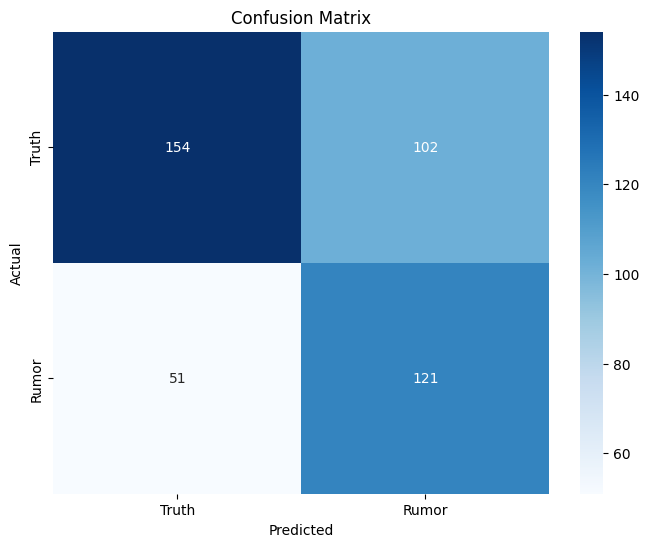

Confusion matrix saved to: confusion_matrix.png


In [37]:
# Display and Plot Confusion Matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = results['confusion_matrix']
print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Truth", "Rumor"], yticklabels=["Truth", "Rumor"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.savefig("confusion_matrix.png")
plt.show()
print("Confusion matrix saved to: confusion_matrix.png")


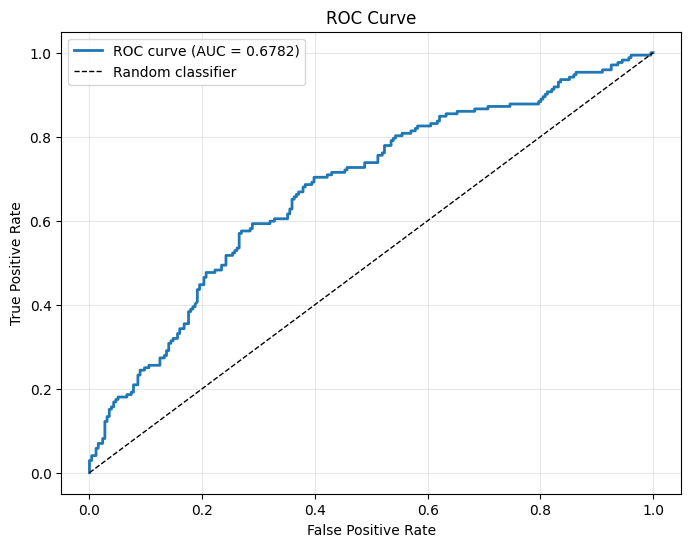

ROC curve saved to: roc_curve.png


In [38]:
# Display ROC Curve
import matplotlib.pyplot as plt

fpr = results['fpr']
tpr = results['tpr']
test_roc_auc = results['roc_auc']

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {test_roc_auc:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random classifier', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("roc_curve.png")
plt.show()
print("ROC curve saved to: roc_curve.png")
